# Grad-CAM: Szybkie dotrenowanie klasyfikatora + interpretowalność

## Cel eksperymentu

Szybkie dotrenowanie (fine-tuning) lekkiego klasyfikatora na danych BUSI (benign/malignant/normal), a następnie wykonanie Grad-CAM na tym dotrenowanym modelu.



## Instalacja zależności (opcjonalna)

Uruchom poniższą komórkę, jeśli `grad-cam` nie jest zainstalowany.

In [22]:
# [OPCJONALNE] Odkomentuj i uruchom, jeśli grad-cam nie jest zainstalowany
# !pip install grad-cam

## Import bibliotek

In [23]:
import os
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM: {vram_gb:.1f} GB")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA T1200 Laptop GPU
VRAM: 3.6 GB


## Konfiguracja

Zmień poniższe parametry w razie potrzeby:
- `BATCH_SIZE`: zmniejsz do 4 lub 2 jeśli wystąpi CUDA Out of Memory
- `MODEL_NAME`: `"resnet18"` (lżejszy) lub `"resnet50"` (lepszy, ale wolniejszy)
- `NUM_EPOCHS`: więcej epok = lepszy model, ale dłuższy trening

In [24]:
# === KONFIGURACJA — EDYTUJ TUTAJ ===
MODEL_NAME = "resnet18"         # "resnet18" lub "resnet50"
IMG_SIZE = 224
BATCH_SIZE = 8                   # Zmniejsz do 4 lub 2 przy CUDA OOM
NUM_EPOCHS = 3                   # 3-5 epok dla szybkiego eksperymentu
LEARNING_RATE = 1e-3
NUM_WORKERS = 0                  # 0 dla kompatybilności (Windows/Mac)
SEED = 42
NUM_CLASSES = 3
CLASS_NAMES = ['benign', 'malignant', 'normal']

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

CHECKPOINT_DIR = 'checkpoints'
OUTPUT_DIR = 'gradcam_outputs/option_C'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"Model: {MODEL_NAME}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")

Device: cuda
Model: resnet18
Batch size: 8
Epochs: 3


## Przygotowanie danych

Automatyczne wykrywanie folderu z danymi. Filtrowanie masek segmentacyjnych.

**Uwaga dot. splitu:** Docelowo powinno się użyć splitu grupowego, aby uniknąć data leakage między oryginalnymi i zaszumionymi (`__noise_`) kopiami obrazów. W tym szybkim eksperymencie stosujemy prosty random split z grupowaniem po nazwie bazowej.

In [25]:
def find_dataset_root():
    """Automatycznie znajduje folder z danymi klasyfikacyjnymi BUSI."""
    base = Path('.')
    candidates = [
        base / 'Dataset_BUSI_noisy',
        base / 'Dataset_BUSI_with_GT',
    ]
    for candidate in candidates:
        if candidate.exists():
            subdirs = {d.name for d in candidate.iterdir() if d.is_dir()}
            if {'benign', 'malignant', 'normal'}.issubset(subdirs):
                return candidate
    for folder in base.rglob('*'):
        if folder.is_dir():
            subdirs = {d.name for d in folder.iterdir() if d.is_dir()}
            if {'benign', 'malignant', 'normal'}.issubset(subdirs):
                return folder
    raise FileNotFoundError(
        "Nie znaleziono folderu z danymi BUSI.\n"
        "Oczekiwany folder z podfolderami: benign/, malignant/, normal/\n"
        "Ustaw ścieżkę ręcznie: DATASET_ROOT = Path('ścieżka/do/danych')"
    )


DATASET_ROOT = find_dataset_root()
print(f"Dataset root: {DATASET_ROOT.resolve()}")

Dataset root: /home/o0i3z3/university/dl/p2/neural_networks_project/Dataset_BUSI_noisy


In [26]:
class BUSIImageFolder(datasets.ImageFolder):
    """ImageFolder z filtrowaniem masek segmentacyjnych (_mask)."""
    
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform, is_valid_file=self._is_valid)
    
    @staticmethod
    def _is_valid(path):
        path = Path(path)
        if path.suffix.lower() not in {'.png', '.jpg', '.jpeg', '.bmp'}:
            return False
        if '_mask' in path.stem:
            return False
        return True


# Transformacje
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # BUSI -> RGB
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Wczytanie pełnego datasetu (bez augmentacji do podziału)
full_dataset = BUSIImageFolder(str(DATASET_ROOT), transform=val_transform)
print(f"Pełny dataset: {len(full_dataset)} obrazów")
print(f"Klasy: {full_dataset.class_to_idx}")

Pełny dataset: 980 obrazów
Klasy: {'benign': 0, 'malignant': 1, 'normal': 2}


In [27]:
def case_id(filepath):
    """Wyodrębnia ID bazowe przypadku (bez sufiksu __noise_XX)."""
    stem = Path(filepath).stem
    return stem.split('__noise_')[0]


def groupwise_split(dataset, train_ratio=0.70, val_ratio=0.15, seed=SEED):
    """
    Podział na train/val/test z grupowaniem po case_id.
    Oryginalny obraz i jego wersje noisy trafiają do tego samego podzbioru.
    """
    rng = random.Random(seed)
    
    # Grupowanie indeksów po case_id i klasie
    groups = {}  # (class_idx, case_id) -> [indices]
    for idx, (path, class_idx) in enumerate(dataset.samples):
        cid = case_id(path)
        key = (class_idx, cid)
        groups.setdefault(key, []).append(idx)
    
    train_indices, val_indices, test_indices = [], [], []
    
    # Split per class
    class_groups = {}  # class_idx -> list of (case_id, indices)
    for (class_idx, cid), indices in groups.items():
        class_groups.setdefault(class_idx, []).append((cid, indices))
    
    for class_idx in sorted(class_groups.keys()):
        items = class_groups[class_idx]
        rng.shuffle(items)
        n = len(items)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        
        for i, (cid, indices) in enumerate(items):
            if i < n_train:
                train_indices.extend(indices)
            elif i < n_train + n_val:
                val_indices.extend(indices)
            else:
                test_indices.extend(indices)
    
    return train_indices, val_indices, test_indices


train_indices, val_indices, test_indices = groupwise_split(full_dataset)
print(f"Split (grupowy, bez data leakage):")
print(f"  Train: {len(train_indices)} obrazów")
print(f"  Val:   {len(val_indices)} obrazów")
print(f"  Test:  {len(test_indices)} obrazów")

Split (grupowy, bez data leakage):
  Train: 685 obrazów
  Val:   144 obrazów
  Test:  151 obrazów


In [28]:
# Datasety z odpowiednimi transformacjami
train_dataset_aug = BUSIImageFolder(str(DATASET_ROOT), transform=train_transform)
train_subset = Subset(train_dataset_aug, train_indices)
val_subset = Subset(full_dataset, val_indices)
test_subset = Subset(full_dataset, test_indices)

# DataLoadery
train_loader = DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_subset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_subset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)

print(f"Batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}")

Batches: train=86, val=18, test=19


## Model

Budowa modelu z zamrożonym backbone i nową warstwą klasyfikacyjną (3 klasy BUSI).

In [29]:
def build_model(model_name, num_classes=NUM_CLASSES):
    """Buduje model z zamrożonym backbone i nową warstwą klasyfikacyjną."""
    if model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    else:
        raise ValueError(f"Nieobsługiwany model: {model_name}. Użyj 'resnet18' lub 'resnet50'.")
    
    # Zamrożenie backbone
    for param in model.parameters():
        param.requires_grad = False
    
    # Nowa warstwa klasyfikacyjna (trenovalna)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    
    return model


model = build_model(MODEL_NAME)
model = model.to(DEVICE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model: {MODEL_NAME}")
print(f"Parametry treningowe: {trainable_params:,} / {total_params:,} ({trainable_params/total_params:.2%})")

Model: resnet18
Parametry treningowe: 1,539 / 11,178,051 (0.01%)


## Trening

Szybki trening z zamrożonym backbone. Jeśli wystąpi **CUDA Out of Memory**, zmniejsz `BATCH_SIZE` do 4 lub 2 w komórce konfiguracyjnej powyżej i uruchom ponownie.

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

best_val_acc = 0.0
best_model_state = None
best_epoch = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
NUM_EPOCHS=20
checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{MODEL_NAME}_quick_busi_best.pth")

print(f"Rozpoczynam trening ({NUM_EPOCHS} epok)...")
print("=" * 65)

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X.size(0)
        train_correct += outputs.argmax(1).eq(y).sum().item()
        train_total += y.size(0)
    
    train_loss /= train_total
    train_acc = train_correct / train_total
    
    # --- Validation ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            outputs = model(X)
            loss = criterion(outputs, y)
            val_loss += loss.item() * X.size(0)
            val_correct += outputs.argmax(1).eq(y).sum().item()
            val_total += y.size(0)
    
    val_loss /= val_total
    val_acc = val_correct / val_total
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    tag = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        tag = ' <- best'
    
    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS}  "
        f"train_loss: {train_loss:.4f}  train_acc: {train_acc:.4f}  |  "
        f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}{tag}"
    )

print("=" * 65)
print(f"Najlepszy model: epoka {best_epoch}, val_acc: {best_val_acc:.4f}")

Rozpoczynam trening (20 epok)...
Epoch 1/20  train_loss: 1.0024  train_acc: 0.4905  |  val_loss: 0.8774  val_acc: 0.5764 <- best
Epoch 2/20  train_loss: 0.8277  train_acc: 0.6350  |  val_loss: 0.8963  val_acc: 0.6111 <- best
Epoch 3/20  train_loss: 0.8028  train_acc: 0.6321  |  val_loss: 0.8035  val_acc: 0.6111
Epoch 4/20  train_loss: 0.7347  train_acc: 0.7036  |  val_loss: 0.7763  val_acc: 0.6806 <- best
Epoch 5/20  train_loss: 0.7030  train_acc: 0.7139  |  val_loss: 0.7287  val_acc: 0.6597
Epoch 6/20  train_loss: 0.6945  train_acc: 0.6978  |  val_loss: 0.7512  val_acc: 0.7014 <- best
Epoch 7/20  train_loss: 0.7035  train_acc: 0.6803  |  val_loss: 0.7492  val_acc: 0.6667
Epoch 8/20  train_loss: 0.6341  train_acc: 0.7460  |  val_loss: 0.7082  val_acc: 0.6944
Epoch 9/20  train_loss: 0.6712  train_acc: 0.7255  |  val_loss: 0.7081  val_acc: 0.6806
Epoch 10/20  train_loss: 0.5966  train_acc: 0.7533  |  val_loss: 0.6949  val_acc: 0.7014
Epoch 11/20  train_loss: 0.6098  train_acc: 0.7343  | 

In [31]:
# Zapis checkpointu
idx_to_class = {v: k for k, v in full_dataset.class_to_idx.items()}

checkpoint = {
    'model_state_dict': best_model_state,
    'class_to_idx': full_dataset.class_to_idx,
    'idx_to_class': idx_to_class,
    'model_name': MODEL_NAME,
    'img_size': IMG_SIZE,
    'best_val_acc': best_val_acc,
    'epoch': best_epoch,
    'num_classes': NUM_CLASSES,
    'normalization': {'mean': IMAGENET_MEAN, 'std': IMAGENET_STD},
}

torch.save(checkpoint, checkpoint_path)
print(f"Checkpoint zapisany: {checkpoint_path}")
print(f"  model: {MODEL_NAME}")
print(f"  best_val_acc: {best_val_acc:.4f}")
print(f"  epoch: {best_epoch}")
print(f"  class_to_idx: {full_dataset.class_to_idx}")

Checkpoint zapisany: checkpoints/resnet18_quick_busi_best.pth
  model: resnet18
  best_val_acc: 0.7153
  epoch: 19
  class_to_idx: {'benign': 0, 'malignant': 1, 'normal': 2}


## Ewaluacja na zbiorze testowym

In [32]:
# Wczytanie najlepszego modelu
model.load_state_dict(best_model_state)
model.eval()

# Ewaluacja na test set
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        outputs = model(X)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc = (all_preds == all_labels).mean()

print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test samples: {len(all_labels)}")

Test Accuracy: 0.6490 (64.90%)
Test samples: 151



Classification Report:
              precision    recall  f1-score   support

      benign       0.60      0.67      0.63        45
   malignant       0.72      0.72      0.72        64
      normal       0.59      0.52      0.56        42

    accuracy                           0.65       151
   macro avg       0.64      0.64      0.64       151
weighted avg       0.65      0.65      0.65       151



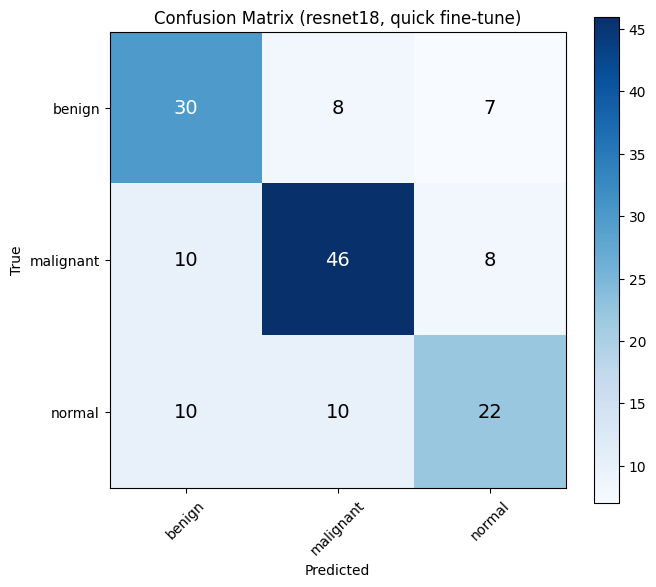

In [33]:
# Confusion Matrix
try:
    from sklearn.metrics import confusion_matrix, classification_report
    
    cm = confusion_matrix(all_labels, all_preds)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
    
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45)
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix ({MODEL_NAME}, quick fine-tune)')
    
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=14)
    
    plt.colorbar(im)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
    plt.show()

except ImportError:
    # Fallback: manually compute confusion matrix
    print("\nConfusion Matrix (sklearn niedostępny, obliczenie manualne):")
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
    for true, pred in zip(all_labels, all_preds):
        cm[true, pred] += 1
    
    print(f"{'':12s} " + " ".join(f"{c:>10s}" for c in CLASS_NAMES))
    for i, cls in enumerate(CLASS_NAMES):
        print(f"{cls:12s} " + " ".join(f"{cm[i,j]:10d}" for j in range(NUM_CLASSES)))
    print(f"\nAccuracy: {(all_preds == all_labels).mean():.4f}")

## Grad-CAM

Generowanie map Grad-CAM na dotrenowanym modelu. Target layer: `model.layer4[-1]`.

In [34]:
# Funkcje pomocnicze dla Grad-CAM

def load_image_for_visualization(img_path, img_size=IMG_SIZE):
    """Wczytuje obraz i zwraca tensor do modelu oraz numpy array do wizualizacji."""
    img = Image.open(img_path).convert('RGB')
    
    preprocess = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    input_tensor = preprocess(img).unsqueeze(0)
    
    vis_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])
    rgb_img = vis_transform(img).permute(1, 2, 0).numpy()
    
    return input_tensor, rgb_img


def denormalize_tensor(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Odwraca normalizację tensora do wizualizacji."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


def generate_gradcam(model, target_layers, input_tensor, target_class=None):
    """Generuje mapę Grad-CAM. Tymczasowo włącza gradienty dla zamrożonego backbone."""
    # Włącz requires_grad dla wszystkich parametrów na czas Grad-CAM
    original_grads = {}
    for name, param in model.named_parameters():
        original_grads[name] = param.requires_grad
        param.requires_grad = True
    
    try:
        targets = [ClassifierOutputTarget(target_class)] if target_class is not None else None
        with GradCAM(model=model, target_layers=target_layers) as cam:
            grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        return grayscale_cam[0]
    finally:
        # Przywróć oryginalne ustawienia gradientów
        for name, param in model.named_parameters():
            param.requires_grad = original_grads[name]


def save_visualization(rgb_img, cam_mask, title, save_path, cam_mask_true=None):
    """Zapisuje wizualizację Grad-CAM."""
    overlay = show_cam_on_image(rgb_img, cam_mask, use_rgb=True)
    
    ncols = 4 if cam_mask_true is not None else 3
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))
    
    axes[0].imshow(rgb_img)
    axes[0].set_title('Oryginalny obraz')
    axes[0].axis('off')
    
    axes[1].imshow(cam_mask, cmap='jet')
    axes[1].set_title('Grad-CAM (predicted)')
    axes[1].axis('off')
    
    axes[2].imshow(overlay)
    axes[2].set_title('Overlay (predicted)')
    axes[2].axis('off')
    
    if cam_mask_true is not None:
        overlay_true = show_cam_on_image(rgb_img, cam_mask_true, use_rgb=True)
        axes[3].imshow(overlay_true)
        axes[3].set_title('Overlay (true class)')
        axes[3].axis('off')
    
    fig.suptitle(title, fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


# Target layer
target_layers = [model.layer4[-1]]
print(f"Target layer: model.layer4[-1] ({type(model.layer4[-1]).__name__})")

Target layer: model.layer4[-1] (BasicBlock)


In [35]:
# Wybór obrazów do Grad-CAM:
# - Po jednym poprawnie sklasyfikowanym z każdej klasy
# - Jeden błędnie sklasyfikowany (jeśli istnieje)

correct_samples = {cls: None for cls in CLASS_NAMES}  # class -> (path, pred, prob)
incorrect_samples = []  # list of (path, true_class, pred_class, prob)

model.eval()
with torch.no_grad():
    for idx in test_indices:
        path, true_label = full_dataset.samples[idx]
        input_tensor, rgb_img = load_image_for_visualization(path)
        input_tensor = input_tensor.to(DEVICE)
        
        output = model(input_tensor)
        probs = torch.nn.functional.softmax(output[0], dim=0)
        pred_idx = probs.argmax().item()
        pred_prob = probs[pred_idx].item()
        
        true_name = idx_to_class[true_label]
        pred_name = idx_to_class[pred_idx]
        
        if pred_idx == true_label and correct_samples[true_name] is None:
            correct_samples[true_name] = (path, pred_name, pred_prob)
        elif pred_idx != true_label and len(incorrect_samples) < 2:
            incorrect_samples.append((path, true_name, pred_name, pred_prob))
        
        # Sprawdź czy mamy wystarczająco próbek
        if all(v is not None for v in correct_samples.values()) and len(incorrect_samples) >= 1:
            break

print("Wybrane obrazy do Grad-CAM:")
print("\nPoprawnie sklasyfikowane:")
for cls, info in correct_samples.items():
    if info:
        print(f"  {cls}: {Path(info[0]).name} -> pred: {info[1]} ({info[2]:.2%})")
    else:
        print(f"  {cls}: brak przykładu")

print(f"\nBłędnie sklasyfikowane: {len(incorrect_samples)} przykład(ów)")
for path, true_cls, pred_cls, prob in incorrect_samples:
    print(f"  {Path(path).name}: true={true_cls}, pred={pred_cls} ({prob:.2%})")

Wybrane obrazy do Grad-CAM:

Poprawnie sklasyfikowane:
  benign: benign (20).png -> pred: benign (75.05%)
  malignant: malignant (154).png -> pred: malignant (97.15%)
  normal: normal (61).png -> pred: normal (88.05%)

Błędnie sklasyfikowane: 2 przykład(ów)
  benign (163)__noise_01.png: true=benign, pred=normal (43.25%)
  benign (203).png: true=benign, pred=malignant (64.33%)



GRAD-CAM: Poprawnie sklasyfikowane obrazy

--- benign ---


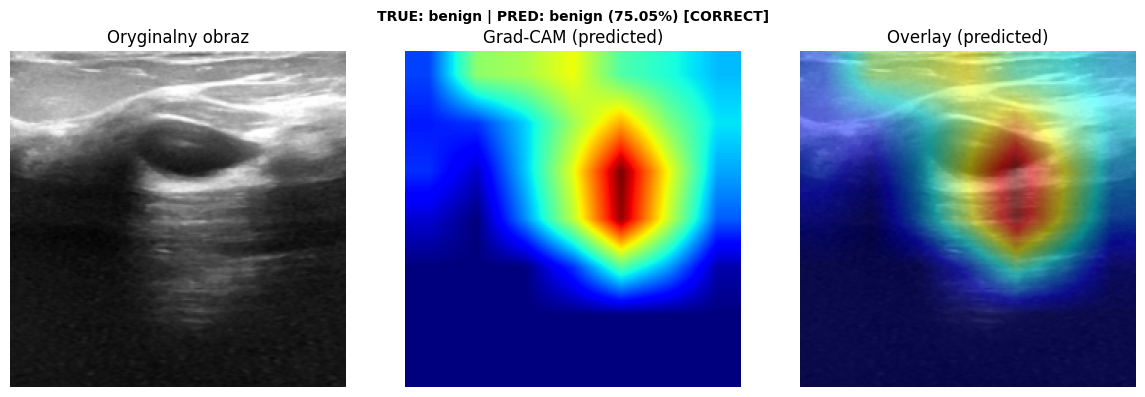

  Zapisano: gradcam_outputs/option_C/gradcam_correct_benign.png

--- malignant ---


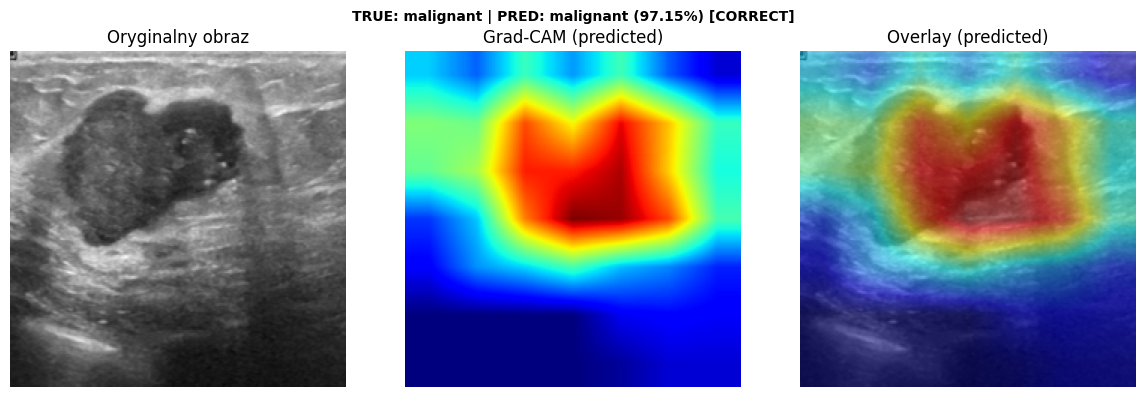

  Zapisano: gradcam_outputs/option_C/gradcam_correct_malignant.png

--- normal ---


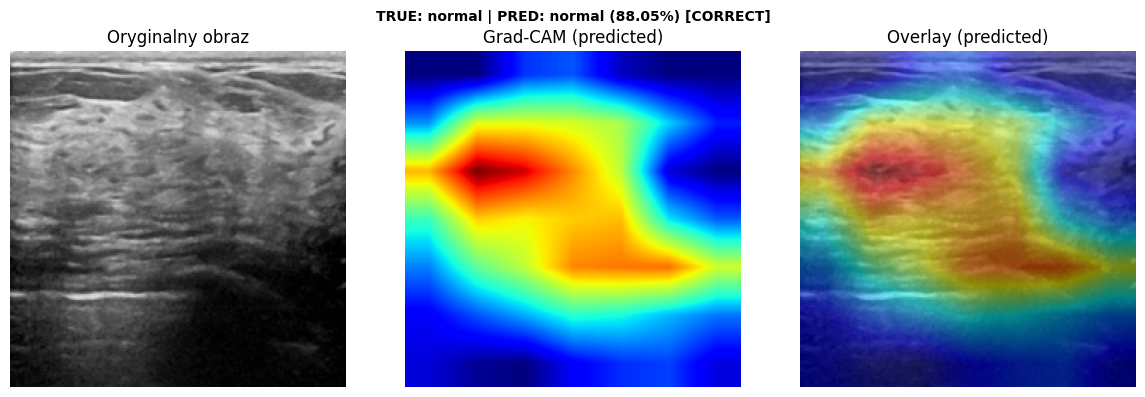

  Zapisano: gradcam_outputs/option_C/gradcam_correct_normal.png


In [36]:
# Generowanie Grad-CAM dla poprawnie sklasyfikowanych
print("\n" + "="*60)
print("GRAD-CAM: Poprawnie sklasyfikowane obrazy")
print("="*60)

for cls, info in correct_samples.items():
    if info is None:
        continue
    path, pred_name, pred_prob = info
    print(f"\n--- {cls} ---")
    
    input_tensor, rgb_img = load_image_for_visualization(path)
    input_tensor = input_tensor.to(DEVICE)
    
    pred_idx = CLASS_NAMES.index(pred_name)
    cam_mask = generate_gradcam(model, target_layers, input_tensor, target_class=pred_idx)
    
    title = f"TRUE: {cls} | PRED: {pred_name} ({pred_prob:.2%}) [CORRECT]"
    save_path = os.path.join(OUTPUT_DIR, f"gradcam_correct_{cls}.png")
    save_visualization(rgb_img, cam_mask, title, save_path)
    print(f"  Zapisano: {save_path}")


GRAD-CAM: Błędnie sklasyfikowane obrazy

--- Błąd #1: true=benign, pred=normal ---


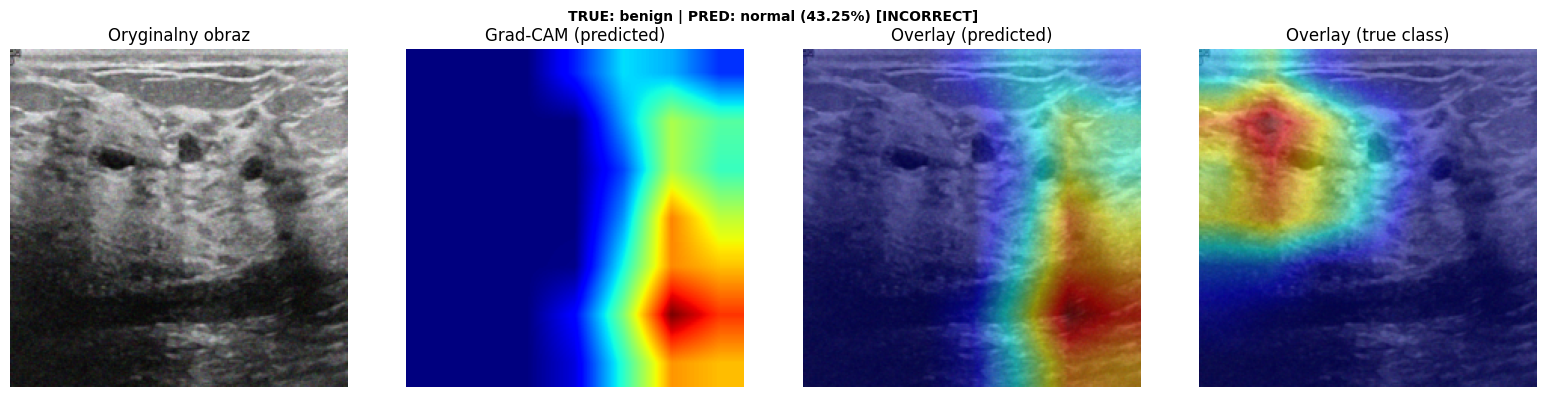

  Zapisano: gradcam_outputs/option_C/gradcam_incorrect_0_benign_as_normal.png

--- Błąd #2: true=benign, pred=malignant ---


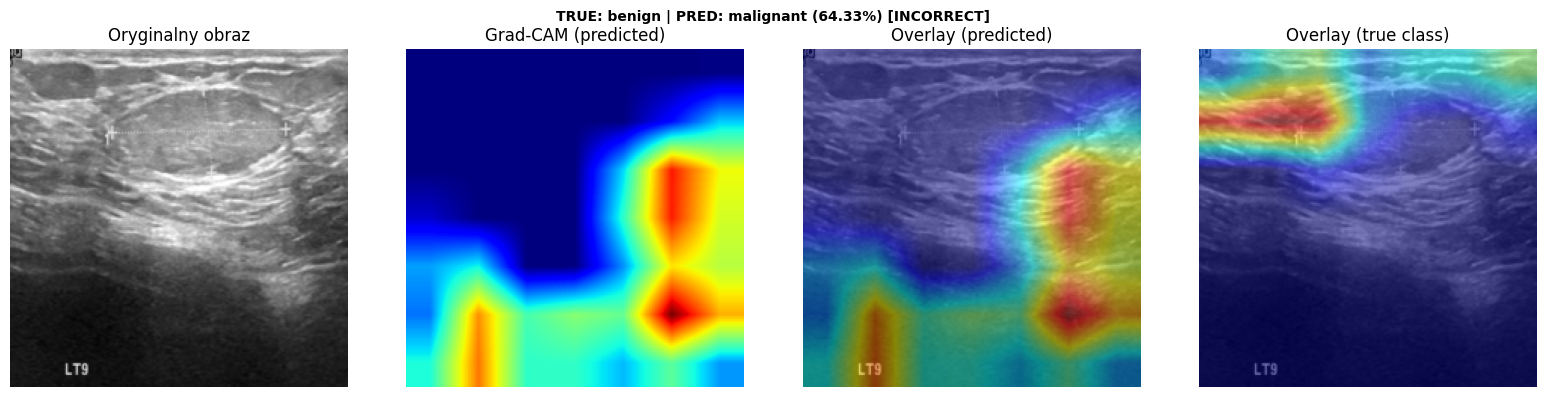

  Zapisano: gradcam_outputs/option_C/gradcam_incorrect_1_benign_as_malignant.png


In [37]:
# Generowanie Grad-CAM dla błędnie sklasyfikowanych
if incorrect_samples:
    print("\n" + "="*60)
    print("GRAD-CAM: Błędnie sklasyfikowane obrazy")
    print("="*60)
    
    for i, (path, true_cls, pred_cls, pred_prob) in enumerate(incorrect_samples):
        print(f"\n--- Błąd #{i+1}: true={true_cls}, pred={pred_cls} ---")
        
        input_tensor, rgb_img = load_image_for_visualization(path)
        input_tensor = input_tensor.to(DEVICE)
        
        pred_idx = CLASS_NAMES.index(pred_cls)
        true_idx = CLASS_NAMES.index(true_cls)
        
        # Grad-CAM dla predicted class
        cam_mask_pred = generate_gradcam(model, target_layers, input_tensor, target_class=pred_idx)
        # Grad-CAM dla true class
        cam_mask_true = generate_gradcam(model, target_layers, input_tensor, target_class=true_idx)
        
        title = f"TRUE: {true_cls} | PRED: {pred_cls} ({pred_prob:.2%}) [INCORRECT]"
        save_path = os.path.join(OUTPUT_DIR, f"gradcam_incorrect_{i}_{true_cls}_as_{pred_cls}.png")
        save_visualization(rgb_img, cam_mask_pred, title, save_path, cam_mask_true=cam_mask_true)
        print(f"  Zapisano: {save_path}")
else:
    print("\nBrak błędnie sklasyfikowanych obrazów w wybranej próbce testowej.")
    print("To może oznaczać, że model dobrze radzi sobie na wybranej podpróbce,")
    print("lub że próbka testowa jest zbyt mała.")

## Wyniki: Podsumowanie

In [38]:
print("\n" + "="*60)
print("PODSUMOWANIE EKSPERYMENTU")
print("="*60)
print(f"\nModel: {MODEL_NAME} (zamrożony backbone + liniowy klasyfikator)")
print(f"Epoki: {NUM_EPOCHS}")
print(f"Najlepsza Val Accuracy: {best_val_acc:.4f} (epoka {best_epoch})")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"\nCheckpoint: {checkpoint_path}")
print(f"Wizualizacje Grad-CAM: {OUTPUT_DIR}/")

output_files = os.listdir(OUTPUT_DIR)
print(f"\nZapisane pliki ({len(output_files)}):")
for f in sorted(output_files):
    print(f"  {f}")


PODSUMOWANIE EKSPERYMENTU

Model: resnet18 (zamrożony backbone + liniowy klasyfikator)
Epoki: 20
Najlepsza Val Accuracy: 0.7153 (epoka 19)
Test Accuracy: 0.6490

Checkpoint: checkpoints/resnet18_quick_busi_best.pth
Wizualizacje Grad-CAM: gradcam_outputs/option_C/

Zapisane pliki (6):
  confusion_matrix.png
  gradcam_correct_benign.png
  gradcam_correct_malignant.png
  gradcam_correct_normal.png
  gradcam_incorrect_0_benign_as_normal.png
  gradcam_incorrect_1_benign_as_malignant.png
